In [2]:
# Importing
import scanpy as sc
import matplotlib.pyplot as plt

sc.settings.verbosity = 3
sc.settings.figdir = '../results/'

In [3]:
adata = sc.datasets.pbmc3k()
print(adata)

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'


In [4]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=['mt'],
    percent_top=None,
    log1p=False,
    inplace=True
)

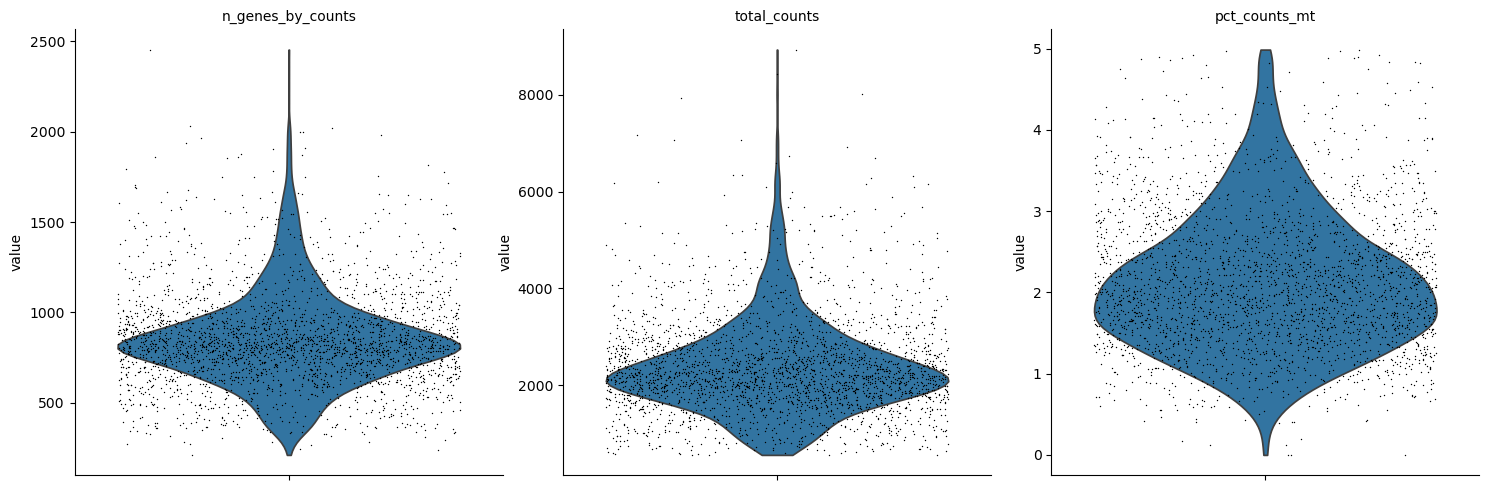

In [7]:
sc.pl.violin(
    adata,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter=0.4,
    multi_panel=True
)

In [9]:
# Keep only cells that have between 200 and 2500 genes, and less than 5% mitochondrial counts
adata = adata[adata.obs.n_genes_by_counts > 200]
adata = adata[adata.obs.n_genes_by_counts < 2500]
adata = adata[adata.obs.pct_counts_mt < 5]

# Filter genes that are expressed in less than 3 cells
sc.pp.filter_genes(adata, min_cells=3)

print(adata)

AnnData object with n_obs × n_vars = 2638 × 13656
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'


In [12]:
import os
os.makedirs('../data', exist_ok=True)

adata.write('../data/pbmc3k_qc.h5ad')